In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# So plots look better by default
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


In [14]:
# Load the data
csv_path = "data/open-meteo-subset.csv"   
df = pd.read_csv(csv_path, parse_dates=["time"])
df = df.set_index("time").sort_index()

# Keep only numeric columns for plotting
num_cols = df.select_dtypes("number").columns.tolist()
num_cols


['temperature_2m (°C)',
 'precipitation (mm)',
 'wind_speed_10m (m/s)',
 'wind_gusts_10m (m/s)',
 'wind_direction_10m (°)']

In [15]:
# Display the first few rows and summary statistics
display(df.head())
display(df[num_cols].describe().T.assign(missing=df[num_cols].isna().sum()))


,temperature_2m (°C),precipitation (mm),wind_speed_10m (m/s),wind_gusts_10m (m/s),wind_direction_10m (°)
time,,,,,
2020-01-01 00:00:00,-2.2,0.1,9.6,21.3,284
2020-01-01 01:00:00,-2.2,0.0,10.6,23.0,282
2020-01-01 02:00:00,-2.3,0.0,11.0,23.5,284
2020-01-01 03:00:00,-2.3,0.0,10.6,23.3,284
2020-01-01 04:00:00,-2.7,0.0,10.6,22.8,284


,count,mean,std,min,25%,50%,75%,max,missing
temperature_2m (°C),8760.0,-0.394909,6.711903,-19.3,-4.9,-1.0,4.1,19.9,0
precipitation (mm),8760.0,0.222854,0.493747,0.0,0.0,0.0,0.2,5.8,0
wind_speed_10m (m/s),8760.0,3.661689,2.253210,0.1,1.8,3.3,5.1,13.6,0
wind_gusts_10m (m/s),8760.0,8.300719,5.098909,0.2,4.5,7.7,11.5,28.7,0
wind_direction_10m (°),8760.0,212.209589,91.371980,0.0,128.0,238.0,292.0,360.0,0


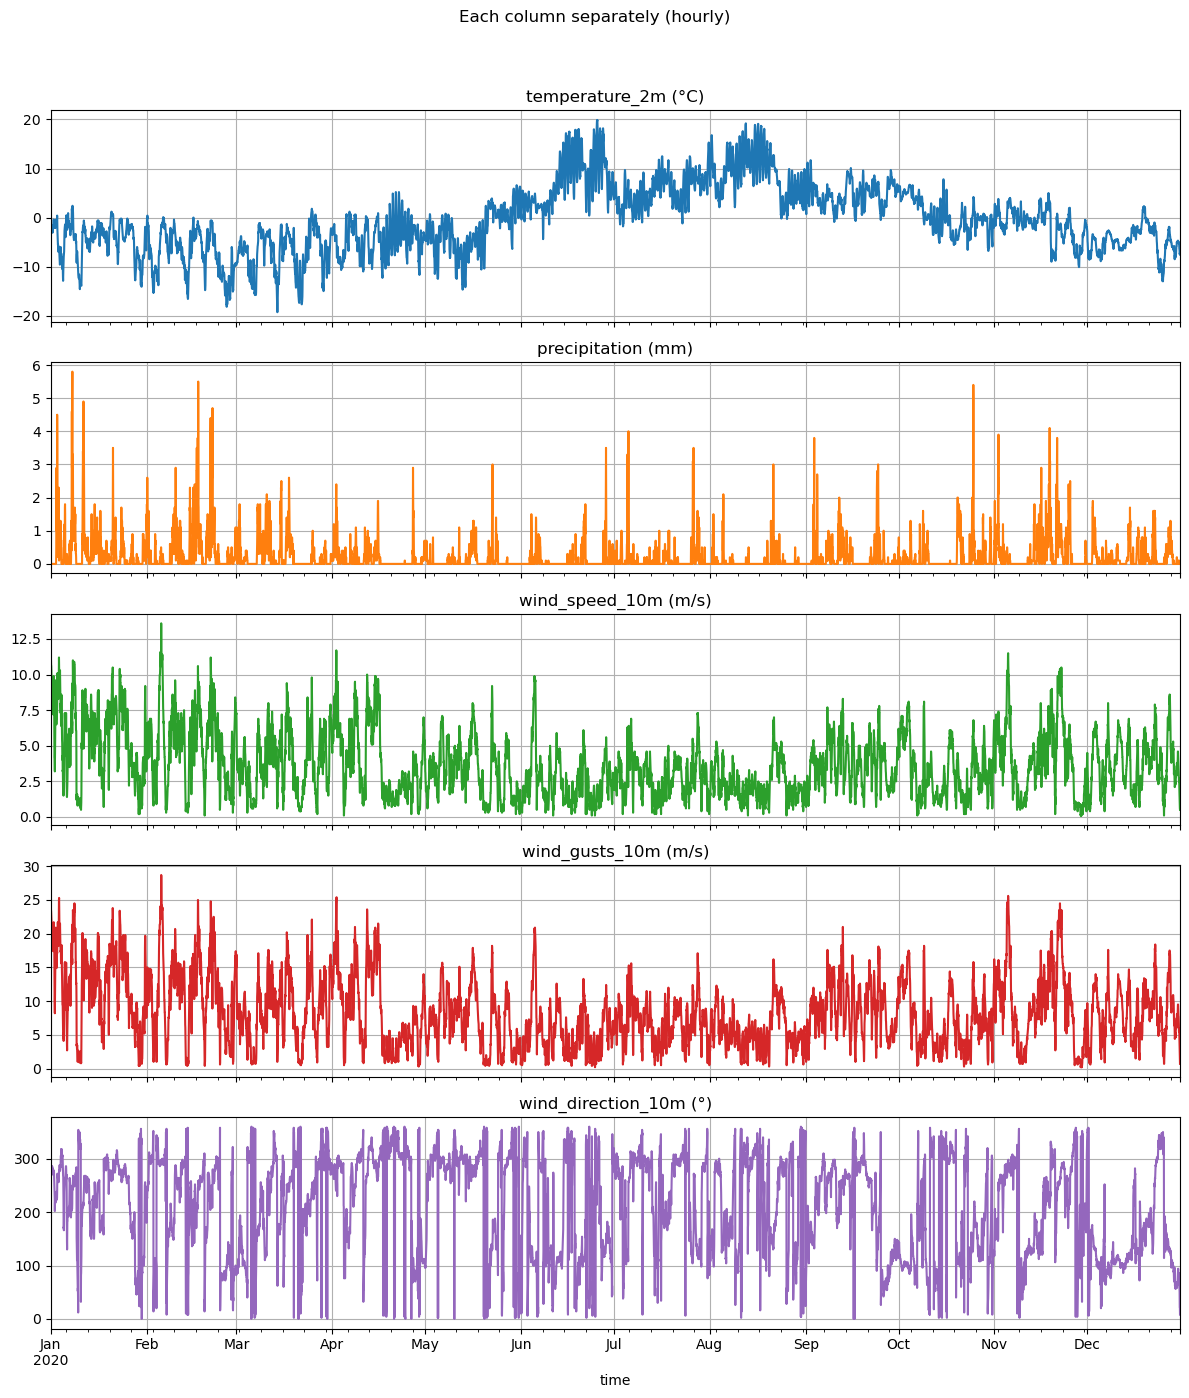

In [16]:
# Plot all numeric columns separately
axes = df[num_cols].plot(
    subplots=True, sharex=True, legend=False,
    layout=(-1, 1), figsize=(12, 2.8 * len(num_cols))
)
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    ax.set_title(col)

plt.suptitle("Each column separately (hourly)", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])



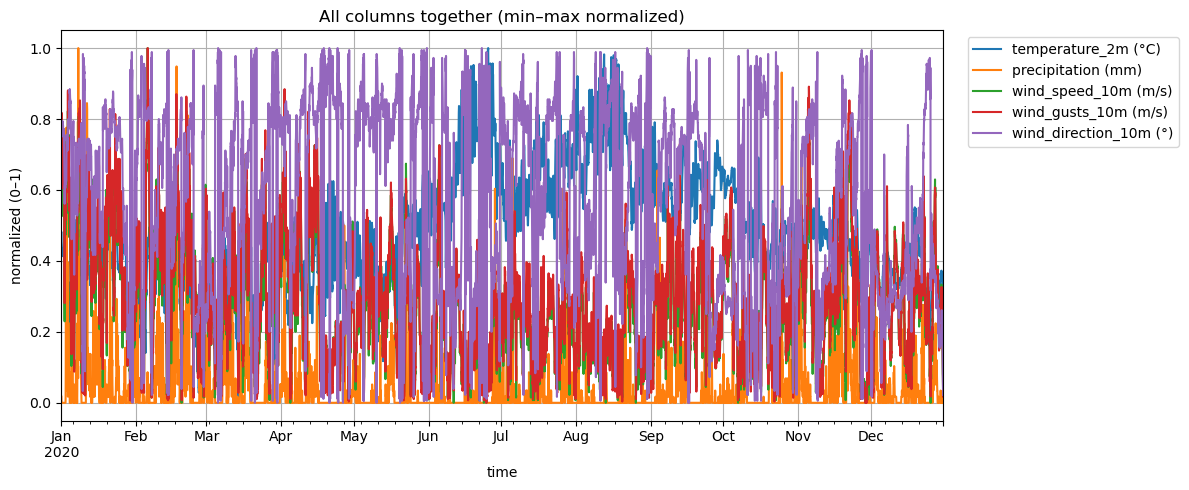

In [17]:
# Plot all numeric columns together (min–max normalized)
norm = (df[num_cols] - df[num_cols].min()) / (df[num_cols].max() - df[num_cols].min())
ax = norm.plot(figsize=(12, 5))
ax.set_title("All columns together (min–max normalized)")
ax.set_ylabel("normalized (0–1)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()





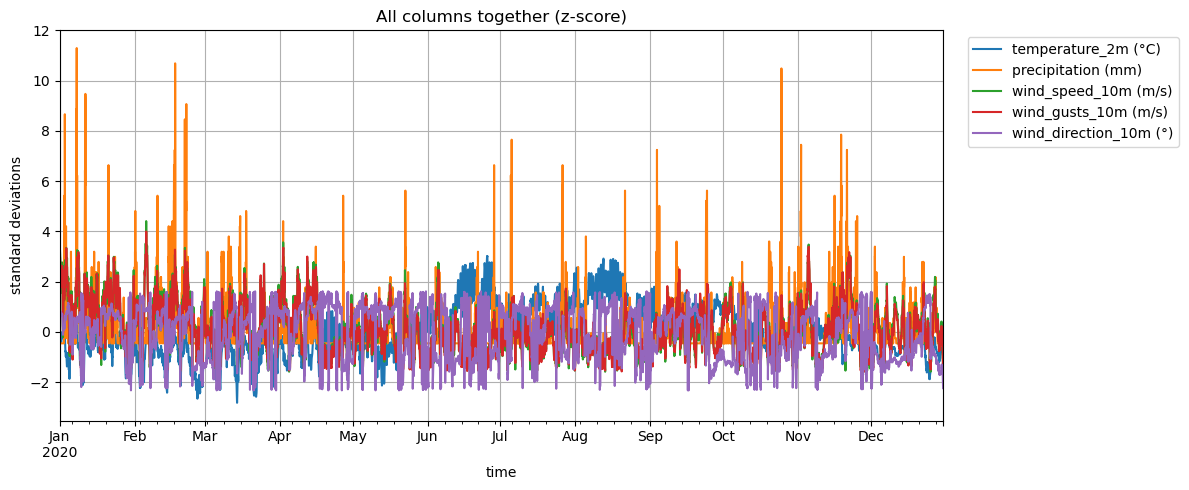

In [18]:
# Plot all numeric columns together (z-score)
z = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std(ddof=0)
ax = z.plot(figsize=(12, 5))
ax.set_title("All columns together (z-score)")
ax.set_ylabel("standard deviations")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


# Project name: 
IND320_project work, part 1
    
# Student name: 
Anura Arembage


## AI Usage
. I used ChatGPT to figure out how to set up the project folders and Streamlit pages, fix error messages, and clean up the code.

. It also helped me with basic Git/GitHub steps (add, commit, push) and small Streamlit changes when something didn’t work.

. For the data work I used pandas to load and check the CSV.

. For charts I used matplotlib to make simple line plots.

. I read the suggestions, tested them, and kept only what fit this project.
. Find solution for Streamlit app stayed on “Connecting…” and showed access-denied behavior due to NMBU firewall/polycy blocked my NMBU computer (Killed stuck Python processes and relaunched on a fresh port: taskkill /F /IM python.exe then streamlit run app.py --server.port 8510.).


## Project Log

At the beginning of this project, I set up a folder structure that included a Jupyter Notebook, a Streamlit app, and a data folder with CSV files. As a beginner, one of the main challenges was understanding how to organize files correctly so that both Jupyter and Streamlit could access the same dataset. I initially had duplicate folders and the Streamlit app was showing an old CSV file, which caused some confusion. After cleaning up the folders and placing the dataset inside a dedicated `data` folder, the system started working as expected.

For the dataset, I used the file `open-meteo-subset.csv`, which contains weather-related data. In Jupyter Notebook, I started by loading the dataset with pandas and performing basic checks, such as previewing the first few rows and generating summary statistics. I also experimented with simple plots to visualize trends in the data, such as temperature changes. These steps helped me build a basic workflow for analyzing data in Python.

Streamlit was used to create an online interface for the same dataset. The Streamlit app loads the CSV file, displays the data, and generates basic statistics. This allows the project to move from a local analysis in Jupyter Notebook to a web-based application that can be shared with others. Learning how to connect these two platforms was a key step in the project.

AI tools were useful throughout the process. I used ChatGPT to clarify instructions, clean up code, and generate examples of how to structure Python code. This support made it possible to focus on understanding the main logic instead of being stuck on small errors. 

In summary, this project has been an introduction to combining Jupyter Notebook for documentation and coding with Streamlit for online presentation. I learned the importance of organizing files, commenting on code. Although the setup process was sometimes confusing, it gave me a better understanding of how local development tools and cloud-based apps can work together. 

import pandas as pd

# Load dataset from the data folder
df = pd.read_csv("data/open-meteo-subset.csv")

# Show first 5 rows
df.head()


## Link
GitHub Repository: https://github.com/Anura-dot/my_streamlit_project
Streamlit App: https://my-ind320-projec.streamlit.app/